In [37]:
from nilearn.maskers import SurfaceLabelsMasker
from nilearn.surface import SurfaceImage
from nilearn.datasets import load_fsaverage
from pathlib import Path
import neuropythy as ny 
import nibabel as nib 
import pandas as pd 


yeo_atlas_dir = Path.home() / ".cache/atlases/Yeo_JNeurophysiol11_FreeSurfer/fsaverage/label"

if not yeo_atlas_dir.exists():
    raise RuntimeError("Could not find Yeo_JNeurophysiol11_FreeSurfer/fsaverage/label in $HOME/.cache/atlases."
                       "Do you need to download it and put it there?"
                       "See https://surfer.nmr.mgh.harvard.edu/fswiki/CorticalParcellation_Yeo2011")

lh_yeo, ctab_lh, names_lh = nib.freesurfer.read_annot(str(yeo_atlas_dir / "lh.Yeo2011_7Networks_N1000.annot"))
rh_yeo, ctab_rh, names_rh = nib.freesurfer.read_annot(str(yeo_atlas_dir / "rh.Yeo2011_7Networks_N1000.annot"))

fsaverage = load_fsaverage("fsaverage7")

labels_img = SurfaceImage(
    mesh=fsaverage["pial"],
    data={
        "left": lh_yeo.squeeze(),
        "right": rh_yeo.squeeze(),
    },
)

labels = ["Background", 'Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
colors = ["#{:02x}{:02x}{:02x}".format(*row[:3]) for row in ctab_lh]
idx = [i for i in range(len(names))]

lut = pd.DataFrame(
    {
        "index": idx,
        "name": labels,
        "colors": colors
    }
)

# labels_img.mesh.to_filename(cache_atlas_dir / "benson14_varea.v4_0_mesh.gii")
# labels_img.data.to_filename(cache_atlas_dir / "benson14_varea.v4_0_data.gii")
# 
# labels_masker = SurfaceLabelsMasker(
#     labels_img=labels_img, lut=lut, verbose=1
# ).fit()



[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


NameError: name 'names' is not defined

In [38]:
ctab_lh

array([[       1,        1,        1,        0,    65793],
       [     120,       18,      134,        0,  8786552],
       [      70,      130,      180,        0, 11829830],
       [       0,      118,       14,        0,   947712],
       [     196,       58,      250,        0, 16399044],
       [     220,      248,      164,        0, 10811612],
       [     230,      148,       34,        0,  2266342],
       [     205,       62,       78,        0,  5127885]], dtype='>i4')

In [2]:
network_names = ["Background", 'Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']

for name in network_names:
    print(f'"{name}": [{name}]')

"Background": [Background]
"Visual": [Visual]
"Somatomotor": [Somatomotor]
"Dorsal Attention": [Dorsal Attention]
"Ventral Attention": [Ventral Attention]
"Limbic": [Limbic]
"Frontoparietal": [Frontoparietal]
"Default": [Default]


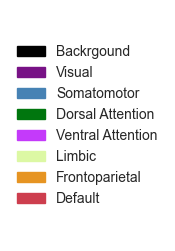

In [29]:
from matplotlib.patches import Patch
import pandas as pd
from matplotlib import pyplot as plt 

network_names = ["Background", 'Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
colors = ["#{:02x}{:02x}{:02x}".format(*row[:3]) for row in ctab_lh]
idx = [i for i in range(len(names))]

lut = pd.DataFrame(
    {
        "index": idx,
        "name": network_names,
        "colors": colors
    }
)


patches = [Patch(color=c, label=l) for c, l in zip(colors, network_names)]
fig, ax = plt.subplots(figsize=(2, 3))
ax.legend(handles=patches, loc="center", frameon=False)
ax.axis("off")
plt.show()



[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_60464/429340345.py:5: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_roi(roi_map=atlas.maps)


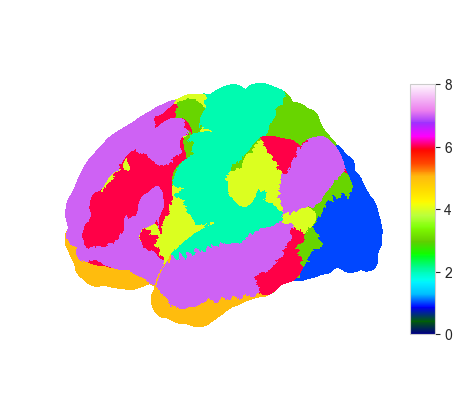

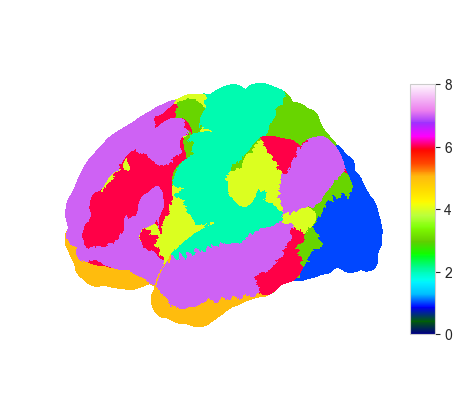

In [1]:
from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn import plotting 

atlas = fetch_atlas("yeo_surf")
plotting.plot_surf_roi(roi_map=atlas.maps)


In [31]:
import pandas as pd 

pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/yeo_surf_roi_run_data.tsv", sep="\t")

,subject,contrast,label,t,cope,varcope,weight,atlas
0,1,mreyemove,Visual,-0.376207,-11.057302,870.616550,2.363444,yeo_surf
1,1,mreyemove,Somatomotor,0.292054,4.795680,499.133524,2.488748,yeo_surf
2,1,mreyemove,Dorsal Attention,-0.173827,-4.431847,411.456215,1.916093,yeo_surf
3,1,mreyemove,Ventral Attention,0.169416,1.383718,335.556779,1.973423,yeo_surf
4,1,mreyemove,Limbic,-0.414920,-9.430880,756.635498,1.145114,yeo_surf
...,...,...,...,...,...,...,...,...
863,33,mreyemove_W-mreyemove_S,Dorsal Attention,-0.972694,-7.798481,79.897314,15.822273,yeo_surf
864,33,mreyemove_W-mreyemove_S,Ventral Attention,-0.670027,-5.866690,69.216703,9.847120,yeo_surf
865,33,mreyemove_W-mreyemove_S,Limbic,0.200434,3.606056,193.923289,4.160547,yeo_surf
866,33,mreyemove_W-mreyemove_S,Frontoparietal,-0.482371,-4.072106,82.132009,8.548729,yeo_surf


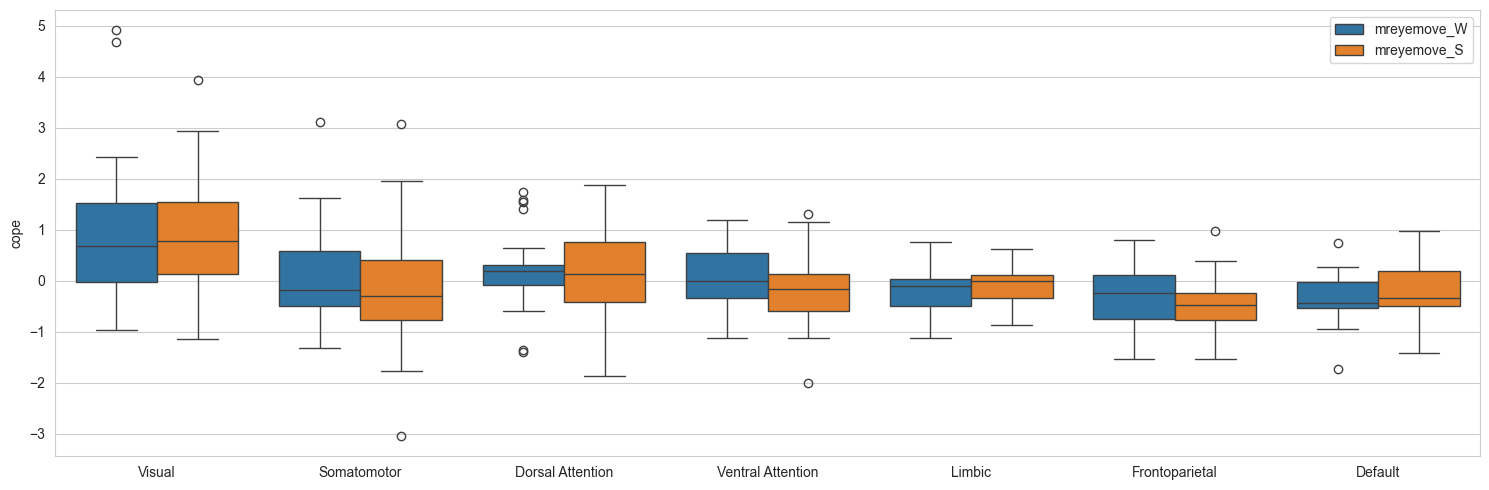

In [34]:
import numpy as np
from matplotlib import pyplot as plt 
from pathlib import Path 

df = pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/yeo_surf_roi_run_data.tsv", sep="\t")

import seaborn as sns

cared_for_contrasts = ["mreyemove_W", "mreyemove_S"]#, "mreyemove_W-mreyemove_S"]
# cared_for_order = ["V1", "V2", "V3"]
# keep only the two contrasts you want to compare
sub = df[df["contrast"].isin(cared_for_contrasts)]

plt.figure(figsize=(15, 5))
sns.boxplot(
    data=sub,
    x="label", y="t", hue="contrast",
    # hue_order=cared_for_order,
    # order=cared_for_contrasts,
)
# plt.axhline(0, color="grey", lw=0.8, ls="--")   # optional t=0 reference
plt.ylabel("cope")

plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
sub

,contrast,atlas,label,t_stat,p_val,n,p_fdr
7,mreyemove_S,yeo_surf,Default,-1.832110,0.073896,31,0.153992
8,mreyemove_S,yeo_surf,Dorsal Attention,1.067124,0.290685,31,0.339133
9,mreyemove_S,yeo_surf,Frontoparietal,-5.006889,0.000050,31,0.000350
10,mreyemove_S,yeo_surf,Limbic,-1.730496,0.091545,31,0.153992
11,mreyemove_S,yeo_surf,Somatomotor,-0.618237,0.539123,31,0.539123
12,mreyemove_S,yeo_surf,Ventral Attention,-1.641609,0.109995,31,0.153992
13,mreyemove_S,yeo_surf,Visual,4.315265,0.000150,31,0.000525
14,mreyemove_W,yeo_surf,Default,-3.893086,0.000400,31,0.001400
15,mreyemove_W,yeo_surf,Dorsal Attention,1.418736,0.169442,31,0.237218
16,mreyemove_W,yeo_surf,Frontoparietal,-2.857286,0.008400,31,0.019599


AttributeError: 'Pandas' object has no attribute 'p_fdr'

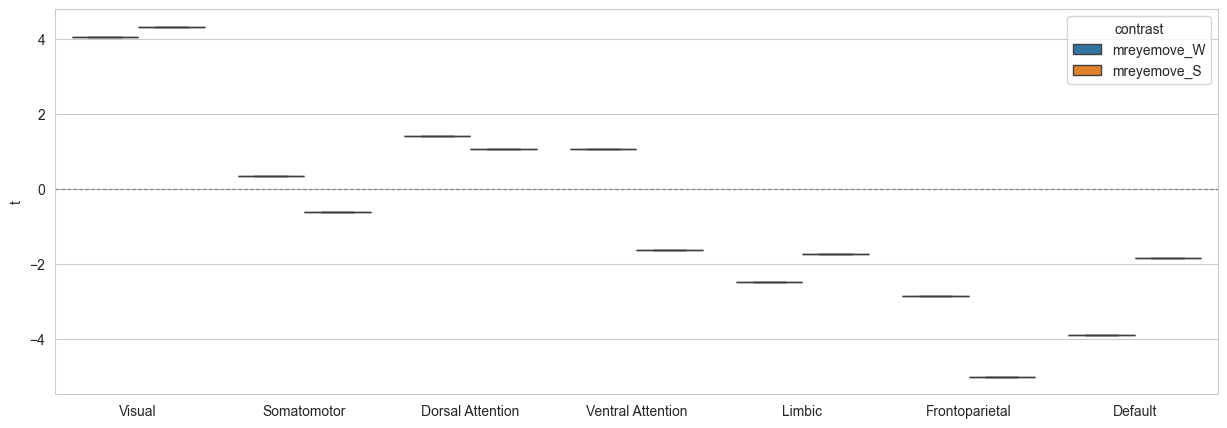

In [33]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# significance table (your df with t_stat / p_val / p_fdr)
stats_df = pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/yeo_surf_roi_run_data.tsv", sep="\t")

order = ["Visual", "Somatomotor", "Dorsal Attention", "Ventral Attention",
         "Limbic", "Frontoparietal", "Default"]      # your preferred label order
hue_order = ["mreyemove_W", "mreyemove_S"]

df = pd.read_csv("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/roi_lme/desc-clean-original-sleep-flame/yeo_surf_roi_test_results_tscores.tsv", sep="\t")
sub = df[df["contrast"].isin(hue_order)]

fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=sub, x="label", y="t_stat", hue="contrast",
            order=order, hue_order=hue_order, ax=ax)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_ylabel("t"); ax.set_xlabel("")

# --- significance lookup (FDR-corrected; switch to "p_val" if you want uncorrected) ---
pcol = "p_fdr"
sig = stats_df[(stats_df["atlas"] == "yeo_surf") & (stats_df["contrast"].isin(hue_order))]
pmap = {(r.contrast, r.label): getattr(r, pcol) for r in sig.itertuples()}

def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

# seaborn dodges hue boxes at i + width*(j+0.5)/n - width/2  (default width=0.8)
n, width = len(hue_order), 0.8
offsets = [width * (j + 0.5) / n - width / 2 for j in range(n)]   # -> [-0.2, +0.2] for 2 hues

yspan = np.diff(ax.get_ylim())[0]
for i, lab in enumerate(order):
    for j, con in enumerate(hue_order):
        p = pmap.get((con, lab))
        if p is None or not stars(p):
            continue
        g = sub[(sub["label"] == lab) & (sub["contrast"] == con)]["t_stat"]
        ax.text(i + offsets[j], g.max() + 0.02 * yspan, stars(p),
                ha="center", va="bottom", fontsize=12)

ax.set_ylim(top=ax.get_ylim()[1] + 0.06 * yspan)   # headroom so top stars don't clip
ax.legend(title="contrast")
fig.tight_layout()
plt.show()